In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot  as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.metrics import (
    r2_score, 
    mean_absolute_error, 
    mean_absolute_percentage_error, 
    root_mean_squared_error, 
    mean_squared_error
)

In [2]:
col_names = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin','name']
data  = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data', sep=r'\s+', na_values='?' ,  names=col_names)

In [3]:
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [4]:
data= data.drop('name' , axis= 1)
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [6]:
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


<Axes: ylabel='horsepower'>

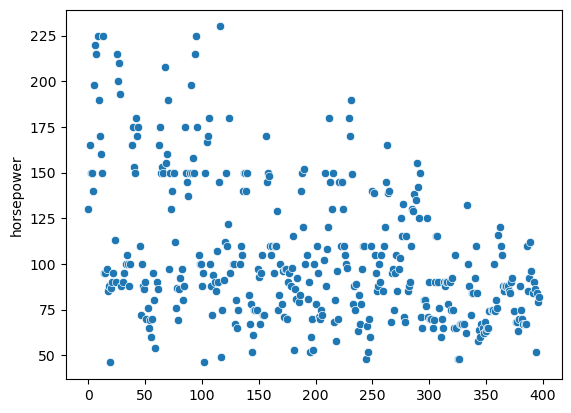

In [7]:
sns.scatterplot(data['horsepower']) 

i showed this graph to choose the optimal fillna method , that if where linear that interpolte would be the best , although not linear but i made it interpolate anyways cause they are just 6 missing horse power values

In [8]:
data = data.fillna(data.interpolate())

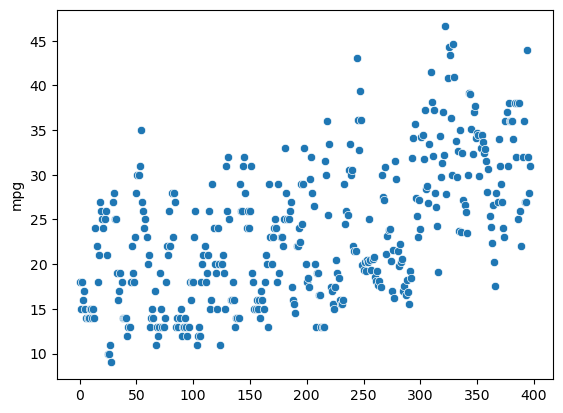

<Axes: xlabel='mpg', ylabel='Count'>

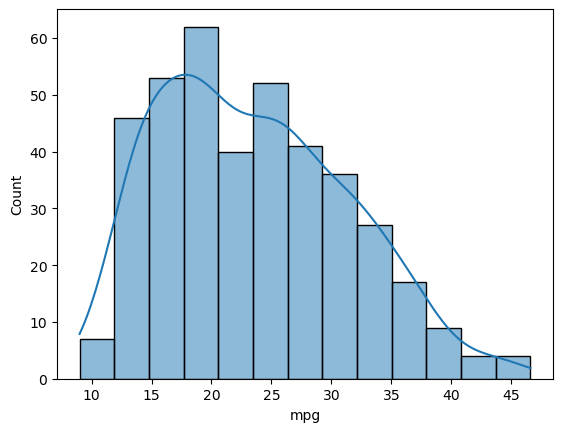

In [9]:
sns.scatterplot(data['mpg']) 
plt.show()
sns.histplot(data['mpg'], kde=True)

the above kde plot indicates that the data is right skewed , which i will resolve in advance !!

<Axes: ylabel='mpg'>

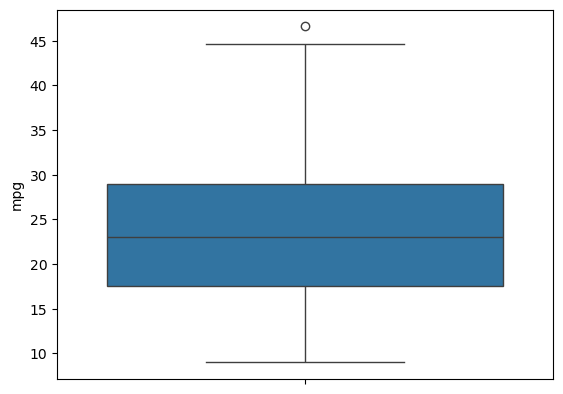

In [10]:
sns.boxplot( data['mpg'] )

one tiny outlier which i guess it is not a big deal, especially it has a value of 46.6 !!

In [11]:
data['mpg'] = np.log1p(data['mpg'])

now to explain why i made this ( log 1 plus x ) thing  : seeing the boxplot has indicating oulier ( the circle at the top ) actually is not of that high concern cause when i did .describe() and saw the max is actually 46 , it is not that big deal !! but the main reason for the log is to make it like bell curve without the skewing to the right !!

<Axes: xlabel='mpg', ylabel='Count'>

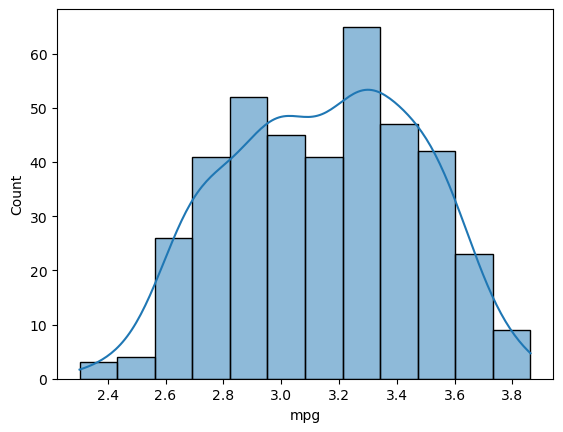

In [12]:
sns.histplot(data['mpg'] , kde = True)

no skewing observed now !

In [13]:
x = data.drop('mpg', axis=1)
y = data['mpg']

i figured out that if u dropped a column without doing inplace =true , you can still read it and copy it , as did for y  ! . as u are not modifing the original data variable !! . that is a note for future me !! 

In [14]:
x_train, x_test, y_train, y_test_log = train_test_split(x, y, test_size=0.3 , random_state=42)

In [15]:
scaler = StandardScaler()
##########################
lin =LinearRegression()
##########################
poly2_reg =LinearRegression()
poly3_reg =LinearRegression()
poly4_reg =LinearRegression()
poly5_reg =LinearRegression()
##########################
lasso = Lasso(max_iter=5000) # this was an ai advice to increas the iterations to converge !!
ridge = Ridge()
##########################
poly_degree_2 = PolynomialFeatures(degree=2)
poly_degree_3 = PolynomialFeatures(degree=3)
poly_degree_4 = PolynomialFeatures(degree=4)
poly_degree_5 = PolynomialFeatures(degree=5)
##########################
prediction_train_regularized = []
prediction_test_regularized = []
prediction_train = []
prediction_test = []
train_RMSE = []
train_R2 = []
test_RMSE = []
test_MAPE = []
test_MSE = []
test_MAE = []
test_R2 = []

In [16]:
x_train_scalled = scaler.fit_transform(x_train) 
test_scalled  = scaler.transform(x_test)
#! this scalled data will be used only in linear model , but the polynomial ones will be scalled after fitting the degrees !! 
y_test = np.expm1(y_test_log)
#! here i removed the log form to make it real mpg values, why i did this so early cause i will not use it in calculations but evaluation !!

NOTE : in the following section i could have used the pipeline() method but wasn't sure that the task required it or to manually do all things my self !

linear_model_part !!

In [17]:
lin.fit(x_train_scalled,y_train)
y_train_1 = np.expm1(lin.predict(x_train_scalled))
y_predict_1 = np.expm1(lin.predict(test_scalled))
prediction_test.append(y_predict_1)
prediction_train.append(y_train_1)

print(f"MSE : {mean_squared_error(y_predict_1, y_test)}")
print(f"MAE : {mean_absolute_error(y_predict_1, y_test)}")
print(f"RMSE : {root_mean_squared_error(y_predict_1, y_test)}")
print(f"MAPE : {mean_absolute_percentage_error(y_predict_1, y_test)}")
print(f"R² : {r2_score(y_test,y_predict_1)}")

MSE : 6.390676143170069
MAE : 1.8432693405160248
RMSE : 2.5279786674673637
MAPE : 0.08413976077653368
R² : 0.888647425150192


poly_degree 2 part !!

In [18]:
train_2 = poly_degree_2.fit_transform(x_train)
test_2 = poly_degree_2.transform(x_test)
train_2 = scaler.fit_transform(train_2)
test_2 = scaler.transform(test_2)
poly2_reg.fit(train_2,y_train)
y_predict_2 = np.expm1(poly2_reg.predict(test_2))
train_predict_2 = np.expm1(poly2_reg.predict(train_2))
prediction_test.append(y_predict_2)
prediction_train.append(train_predict_2)

poly_degree 3 part !!

In [19]:
train_3 = poly_degree_3.fit_transform(x_train)
test_3 = poly_degree_3.transform(x_test)
train_3 = scaler.fit_transform(train_3)
test_3 = scaler.transform(test_3)
poly3_reg.fit(train_3,y_train)
y_predict_3 = np.expm1(poly3_reg.predict(test_3))
train_predict_3 = np.expm1(poly3_reg.predict(train_3))
prediction_test.append(y_predict_3)
prediction_train.append(train_predict_3)

poly_degree 4 part !!

In [20]:
train_4 = poly_degree_4.fit_transform(x_train)
test_4 = poly_degree_4.transform(x_test)
train_4 = scaler.fit_transform(train_4)
test_4 = scaler.transform(test_4)
poly4_reg.fit(train_4,y_train)
y_predict_4 = np.expm1(poly4_reg.predict(test_4))
train_predict_4 = np.expm1(poly4_reg.predict(train_4))
prediction_test.append(y_predict_4)
prediction_train.append(train_predict_4)

poly_degree 5 part !!

In [21]:
train_5 = poly_degree_5.fit_transform(x_train)
test_5 = poly_degree_5.transform(x_test)
train_5 = scaler.fit_transform(train_5)
test_5 = scaler.transform(test_5)
poly5_reg.fit(train_5,y_train)
y_predict_5 = np.expm1(poly5_reg.predict(test_5))
train_predict_5 = np.expm1(poly5_reg.predict(train_5))
prediction_test.append(y_predict_5)
prediction_train.append(train_predict_5)

In [22]:
for data in prediction_train :
    train_RMSE.append(root_mean_squared_error(data,np.expm1(y_train)))
    train_R2.append(r2_score(np.expm1(y_train),data))

for data in prediction_test :
    test_RMSE.append(root_mean_squared_error(data,y_test))
    test_MSE.append(mean_squared_error(data,y_test))
    test_R2.append(r2_score(y_test,data))
    test_MAE.append(mean_absolute_error(y_test,data))
    test_MAPE.append(mean_absolute_percentage_error(y_test,data))

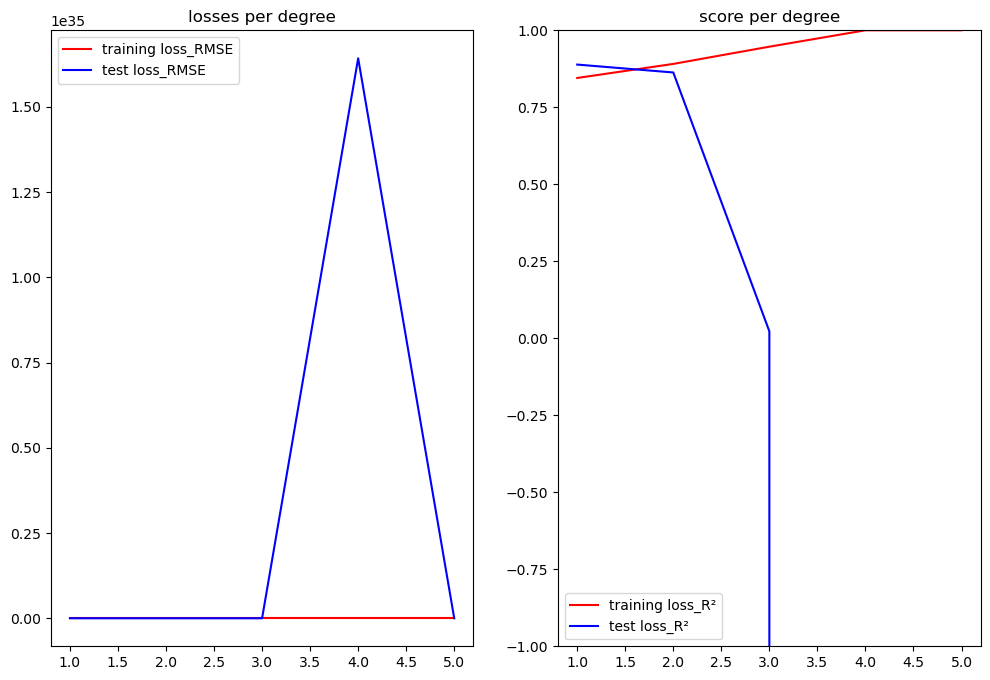

In [23]:
degree = [1, 2, 3 ,4, 5]

fig, ax = plt.subplots(1, 2, figsize=(12, 8))

sns.lineplot(x=degree, y =train_RMSE , ax=ax[0], label = "training loss_RMSE" ,  color = 'r')
sns.lineplot(x=degree, y =test_RMSE , ax=ax[0], label = "test loss_RMSE" ,  color = 'b')

sns.lineplot(x=degree, y =train_R2 , ax=ax[1], label = "training loss_R²" ,  color = 'r')
sns.lineplot(x=degree, y =test_R2 , ax=ax[1], label = "test loss_R²" ,  color = 'b')

ax[0].set_title("losses per degree")
ax[1].set_title("score per degree")
ax[1].set_ylim(-1,1)
plt.legend()
plt.show()

we can say that the model starts overfitting from the the third degree polynomial !! 

Now we will repeat the exact same steps on regularized data whether on ridge or lasso !! but first we will tune the alpha parameters on both !!

In [24]:
# The second degree is the best one 
alpha_values = {'alpha' :[0.001 , 0.01 ,0.1,1,2,3,4,5,10,100]} # will be used for both ridge and lasso !

grid_lasso = GridSearchCV(estimator=lasso  , param_grid=alpha_values, cv = 5 , scoring='r2')
grid_lasso.fit(train_2,y_train) 

grid_ridge = GridSearchCV(estimator=ridge  , param_grid=alpha_values, cv = 5 , scoring='r2')
grid_ridge.fit(train_2,y_train)

print(f"lasso best alpha is :{grid_lasso.best_params_['alpha']} , with R² of : {grid_lasso.best_score_}  ")
print(f"ridge best alpha is :{grid_ridge.best_params_['alpha']} , with R² of : {grid_ridge.best_score_}  ")

lasso best alpha is :0.01 , with R² of : 0.8721468601791502  
ridge best alpha is :0.1 , with R² of : 0.8764731771158015  


ridge's score is slightly higher than of lasso's !!!

In [25]:
lasso_pred = np.expm1(grid_lasso.predict(test_2))
ridge_pred = np.expm1(grid_ridge.predict(test_2))

print('================== lasso ==================')
print(f"MAE : {mean_absolute_error(lasso_pred, y_test)}")
print(f"RMSE : {root_mean_squared_error(lasso_pred, y_test)}")
print(f"MSE : {mean_squared_error(lasso_pred, y_test)}")
print(f"MAPE : {mean_absolute_percentage_error(lasso_pred, y_test)}")
print(f"R² : {r2_score( y_test,lasso_pred)}")

print('================== Ridge ==================')
print(f"MAE : {mean_absolute_error(ridge_pred, y_test)}")
print(f"RMSE : {root_mean_squared_error(ridge_pred, y_test)}")
print(f"MSE : {mean_squared_error(ridge_pred, y_test)}")
print(f"MAPE : {mean_absolute_percentage_error(ridge_pred, y_test)}")
print(f"R² : {r2_score(y_test,ridge_pred )}")

print('================== Unregularized ==================')
print(f"MAE : {mean_absolute_error(y_predict_2, y_test)}")
print(f"RMSE : {root_mean_squared_error(y_predict_2, y_test)}")
print(f"MSE : {mean_squared_error(y_predict_2, y_test)}")
print(f"MAPE : {mean_absolute_percentage_error(y_predict_2, y_test)}")
print(f"R² : {r2_score( y_test,y_predict_2)}")

================== lasso ==================
MAE : 1.7477881234284816
RMSE : 2.426571243685043
MSE : 5.888248000679176
MAPE : 0.076178722987452
R² : 0.8974018458233721
================== Ridge ==================
MAE : 1.789248798226759
RMSE : 2.4098611985458542
MSE : 5.807430996256861
MAPE : 0.07568940462803853
R² : 0.8988100194395068
================== Unregularized ==================
MAE : 1.9970334561697927
RMSE : 2.804228953134331
MSE : 7.863700021596866
MAPE : 0.07990149484819965
R² : 0.8629811266234901


# if we looked at the metrics of the linear model , we will see that the scores are so much close to the regularized models !!  which indicates that the data is not complex !!!  like the model performs well on a one degree higher !!!

Best model evaluation againest other degrees !!

In [26]:
ALL_metrics = {
    "Model": ["Linear Regression","Poly Degree 2","Poly Degree 3" ,"Poly Degree 4","Poly Degree 5","Lasso", "Ridge_best_model"],
    "MAE": [test_MAE[0], test_MAE[1], test_MAE[2], test_MAE[3],test_MAE[4] ,mean_absolute_error(lasso_pred, y_test) , mean_absolute_error(ridge_pred, y_test)],
    "MSE": [test_MSE[0], test_MSE[1], test_MSE[2], test_MSE[3],test_MSE[4] ,mean_squared_error(lasso_pred, y_test) , mean_squared_error(ridge_pred, y_test)],
    "RMSE": [test_RMSE[0], test_RMSE[1], test_RMSE[2], test_RMSE[3],test_RMSE[4] ,root_mean_squared_error(lasso_pred, y_test) , root_mean_squared_error(ridge_pred, y_test)],
    "MAPE": [test_MAPE[0], test_MAPE[1], test_MAPE[2], test_MAPE[3],test_MAPE[4] ,mean_absolute_percentage_error(lasso_pred, y_test) , mean_absolute_percentage_error(ridge_pred, y_test)],
    "R²": [test_R2[0], test_R2[1], test_R2[2], test_R2[3],test_R2[4] ,r2_score(y_test,lasso_pred) , r2_score(y_test,ridge_pred)]
}

metrics_tabel = pd.DataFrame(ALL_metrics)

metrics_tabel

,Model,MAE,MSE,RMSE,MAPE,R²
0,Linear Regression,1.843269e+00,6.390676e+00,2.527979e+00,8.418250e-02,8.886474e-01
1,Poly Degree 2,1.997033e+00,7.863700e+00,2.804229e+00,8.383518e-02,8.629811e-01
2,Poly Degree 3,3.422180e+00,5.609571e+01,7.489707e+00,1.392291e-01,2.257580e-02
3,Poly Degree 4,1.499544e+34,2.698359e+70,1.642668e+35,6.327190e+32,-4.701681e+68
4,Poly Degree 5,1.487034e+15,2.632258e+32,1.622424e+16,8.749458e+13,-4.586506e+30
5,Lasso,1.747788e+00,5.888248e+00,2.426571e+00,7.617872e-02,8.974018e-01
6,Ridge_best_model,1.789249e+00,5.807431e+00,2.409861e+00,7.568940e-02,8.988100e-01


about ridge (best model) :

'RMSE' is lower which means ridge shrunk the outliers than of lasso 

'MSE' same concept for RMSE but the difference is RMSE treats as the same unit of the mpg which makes it easy to interpret than MSE

'MAE' it treates all errors lineary here , why lasso wins here is because lasso zeros features out (linear way) it gives a slightly better accuracy here !

'MAPE' means the model is off by 7% of the averge slightly lower than of lasso's

'R²' means how much variance of the dependant variable explained by the independant variable , a higher one means good fit 

residual plotting !!

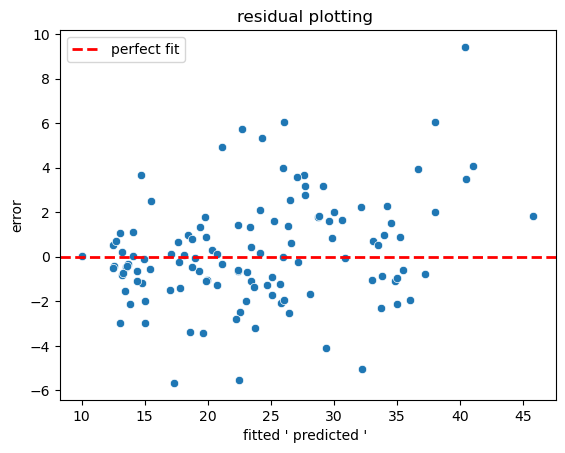

In [27]:
error = ridge_pred - y_test
fitted = ridge_pred
sns.scatterplot(x=fitted ,y = error)
plt.title("residual plotting ")
plt.xlabel("fitted ' predicted ' ")
plt.ylabel("error")
plt.axhline(y=0 , c  ='r' , linestyle = '--' , linewidth = 2 ,   label = 'perfect fit')
plt.legend()
plt.show()

From this graph, we can clearly see that it exhibits *homoscedasticity* because the residuals are randomly scattered around the perfect fit line. This indicates constant variance across the data, whether for low or high MPG values, with no funnel shape present. This favorable outcome is a result of applying `log1p` transformation to the target variable early in the process, which not only removed skewness but also stabilized the variance.

finale insights : the second polynomial degree works well in this type of regression ! but regularizing it gives much better accuracy , giving an R² of 0.89 means there is higher  variance amoung the independant features , which implies that the  data is full of redundant, highly correlated relationships that require a penalty to keep the math stable.